<a href="https://colab.research.google.com/github/yogasaputra2896/analisisdata_kelahiran_jawabarat_2012_2023/blob/main/Forum_9_Analitik_Dan_Vidualidasi_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SOAL NO 1**

In [52]:
# Import Library
import sqlite3

# Membuat Koneksi ke SQLite
conn = sqlite3.connect('perpustakaan.db')
# Membuat Cursor
cursor = conn.cursor()

# Membuat Table Buku
cursor.execute("""
CREATE TABLE IF NOT EXISTS buku (
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  judul TEXT NOT NULL,
  penulis TEXT NOT NULL,
  tahun INTEGER
);
""")

# Membuat Table Anggota
cursor.execute("""
CREATE TABLE IF NOT EXISTS anggota (
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  nama TEXT NOT NULL,
  email TEXT NOT NULL
);
""")

# Membuat tabel Peminjaman
cursor.execute("""
CREATE TABLE IF NOT EXISTS peminjaman (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    id_anggota INTEGER,
    id_buku INTEGER,
    tgl_pinjam TEXT,
    tgl_kembali TEXT,
    FOREIGN KEY (id_anggota) REFERENCES anggota(id),
    FOREIGN KEY (id_buku) REFERENCES buku(id)
);
""")

# Simpan Ke Database
conn.commit()

# A. Menambah 5 Buku
buku_data = [
    ('Laskar Pelangi', 'Andrea Hirata', 2005),
    ('Bumi Manusia', 'Pramoedya Ananta Toer', 1980),
    ('Negeri 5 Menara', 'Ahmad Fuadi', 2009),
    ('Pulang', 'Leila S. Chudori', 2012),
    ('Cantik Itu Luka', 'Eka Kurniawan', 2002)
]
cursor.executemany("INSERT INTO buku (judul, penulis, tahun) VALUES (?, ?, ?);", buku_data)

# A. Menambah 3 Anggota
anggota_data = [
    ('Yoga Saputra', 'yoga@gmail.com'),
    ('Budi Agung', 'budi@gmail.com'),
    ('Bagas Rafi', 'bagas@gmail.com')
]
cursor.executemany("INSERT INTO anggota (nama, email) VALUES (?, ?);", anggota_data)

# Simpan Ke Database
conn.commit()


# B. Tambahkan 4 Transaksi Peminjaman
peminjaman_data = [
    (1, 1, '2025-11-01', '2025-11-05'),
    (2, 3, '2025-11-02', '2025-11-06'),
    (3, 2, '2025-11-03', None),
    (1, 5, '2025-11-04', '2025-11-07')
]
cursor.executemany("""
INSERT INTO peminjaman (id_anggota, id_buku, tgl_pinjam, tgl_kembali)
VALUES (?, ?, ?, ?);
""", peminjaman_data)

# Simpan Ke Database
conn.commit()

# C. Tampilkan daftar peminjaman lengkap
print("==========================")
print("Daftar Peminjaman Lengkap ")
print("==========================")
query_join = """
SELECT
    p.id,
    a.nama AS nama_anggota,
    b.judul AS judul_buku,
    p.tgl_pinjam,
    p.tgl_kembali
FROM peminjaman p
JOIN anggota a ON p.id_anggota = a.id
JOIN buku b ON p.id_buku = b.id;
"""
df_join = pd.read_sql_query(query_join, conn)
display(df_join)


# D. Hitung jumlah total buku yang dipinjam oleh masing-masing anggota
print("")
print("======================================")
print("Jumlah Buku yang Dipinjam per Anggota ")
print("======================================")
query_group = """
SELECT
    a.nama AS nama_anggota,
    COUNT(p.id_buku) AS total_buku_dipinjam
FROM peminjaman p
JOIN anggota a ON p.id_anggota = a.id
GROUP BY a.id;
"""
df_group = pd.read_sql_query(query_group, conn)
display(df_group)

# Tutup koneksi
conn.close()

Daftar Peminjaman Lengkap 


,id,nama_anggota,judul_buku,tgl_pinjam,tgl_kembali
0,1,Yoga Saputra,Laskar Pelangi,2025-11-01,2025-11-05
1,2,Budi Agung,Negeri 5 Menara,2025-11-02,2025-11-06
2,3,Bagas Rafi,Bumi Manusia,2025-11-03,None
3,4,Yoga Saputra,Cantik Itu Luka,2025-11-04,2025-11-07



Jumlah Buku yang Dipinjam per Anggota 


,nama_anggota,total_buku_dipinjam
0,Yoga Saputra,2
1,Budi Agung,1
2,Bagas Rafi,1


**SOAL NO 2**

DataFrame hasil query SQL
   id  nama_anggota       judul_buku  tgl_pinjam tgl_kembali
0   1  Yoga Saputra   Laskar Pelangi  2025-11-01  2025-11-05
1   2    Budi Agung  Negeri 5 Menara  2025-11-02  2025-11-06
2   3    Bagas Rafi     Bumi Manusia  2025-11-03        None
3   4  Yoga Saputra  Cantik Itu Luka  2025-11-04  2025-11-07

Eksplorasi Data Sederhana
Rata-rata durasi peminjaman: 3 hari

Jumlah buku dipinjam per anggota:
- Yoga Saputra: 2 buku
- Budi Agung: 1 buku
- Bagas Rafi: 1 buku



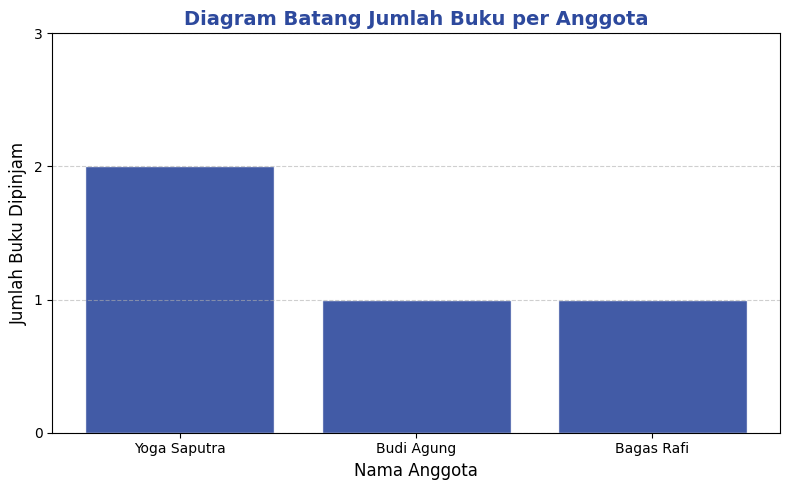

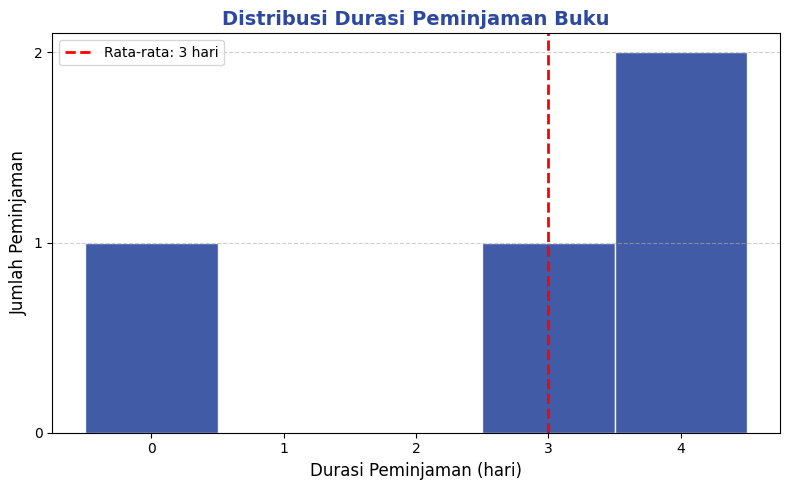

In [61]:
# Import Library
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# A. Membuat DataFrame dari Query SQL
# Koneksi ke database
conn = sqlite3.connect('perpustakaan.db')

query = """
SELECT
    p.id,
    a.nama AS nama_anggota,
    b.judul AS judul_buku,
    p.tgl_pinjam,
    p.tgl_kembali
FROM peminjaman p
JOIN anggota a ON p.id_anggota = a.id
JOIN buku b ON p.id_buku = b.id;
"""

df = pd.read_sql_query(query, conn)

print("==========================")
print("DataFrame hasil query SQL")
print("==========================")
print(df.head())


# B. Eksplorasi Data Sederhana

df['tgl_pinjam'] = pd.to_datetime(df['tgl_pinjam'], errors='coerce')
df['tgl_kembali'] = pd.to_datetime(df['tgl_kembali'], errors='coerce')

df['durasi_hari'] = (df['tgl_kembali'] - df['tgl_pinjam']).dt.days
df['durasi_hari'] = df['durasi_hari'].fillna(0).astype(int)

rata2 = round(df['durasi_hari'].mean())
print("\n==========================")
print("Eksplorasi Data Sederhana")
print("==========================")
print(f"Rata-rata durasi peminjaman: {rata2} hari")

print("\nJumlah buku dipinjam per anggota:")
jumlah_buku = df['nama_anggota'].value_counts().astype(int)
for nama, total in jumlah_buku.items():
    print(f"- {nama}: {total} buku")

# C. Visualisasi Data

# Grafik Jumlah Buku per Anggota
print("")
plt.figure(figsize=(8,5))
jumlah_buku = df['nama_anggota'].value_counts().astype(int)
bars = plt.bar(
    jumlah_buku.index,
    jumlah_buku.to_numpy(),
    color='#2d499d',
    edgecolor='white',
    alpha=0.9
)

plt.title('Diagram Batang Jumlah Buku per Anggota', fontsize=14, fontweight='bold', color='#2d499d')
plt.xlabel('Nama Anggota', fontsize=12)
plt.ylabel('Jumlah Buku Dipinjam', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.yticks(range(0, jumlah_buku.max() + 2))

plt.tight_layout()
plt.show()


# Grafik Distribusi Durasi Peminjaman Buku
print("")
plt.figure(figsize=(8,5))
bins = np.arange(df['durasi_hari'].min(), df['durasi_hari'].max() + 2) - 0.5
plt.hist(df['durasi_hari'], bins=bins, color='#2d499d', edgecolor='white', alpha=0.9)

plt.title('Distribusi Durasi Peminjaman Buku', fontsize=14, fontweight='bold', color='#2d499d')
plt.xlabel('Durasi Peminjaman (hari)', fontsize=12)
plt.ylabel('Jumlah Peminjaman', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

avg = round(df['durasi_hari'].mean())
plt.axvline(avg, color='red', linestyle='--', linewidth=2, label=f'Rata-rata: {avg} hari')

plt.xticks(range(int(df['durasi_hari'].min()), int(df['durasi_hari'].max()) + 1))
plt.yticks(range(0, int(df['durasi_hari'].value_counts().max()) + 1))

plt.legend()
plt.tight_layout()
plt.show()


# Tutup koneksi database
conn.close()

